# Full inverse map  ε → z → y → ẑ → ε̂   (single forward, single inverse)

Architecture: the **decoder is one forward call** `ε → z → η → y`, and the **encoder is its exact
inverse** `y → ẑ → ε̂`. Symmetric, no special-casing.

```
sample_eps      ε ~ N(0, I)
z_from_eps      z = L_Σ ε              (correlate)         ┐ decoder.forward
y_from_z        y = W z + b + σ·noise  (observe)           ┘
encode          ẑ = E[z | y]           (Gaussian inverse) ┐ encoder.inverse
eps_from_z      ε̂ = L_Σ⁻¹ ẑ            (whiten)            ┘
```

ε is fully recoverable **only when the model is well-specified**: the lengthscale must be
**compatible with the sampling rate**. The governing ratio is **ℓ / Δt** (lengthscale per sampling
step). If ℓ ≫ Δt the series is oversampled — z is nearly low-rank and carries little information
about the white ε (that's not a method failure, it's the wrong model). When **ℓ ≈ Δt** (a few
samples per lengthscale) Σ is full-rank, L_Σ⁻¹ is well-conditioned, and ε round-trips cleanly.


In [1]:
import numpy as np, torch, matplotlib.pyplot as plt
from collections import namedtuple
torch.set_default_dtype(torch.float64)

Q, P, K = 2, 20, 15
N       = 4000
RHO     = 0.7
SIGMA   = 0.5
WZS, JIT = 0.7, 1e-4
Params = namedtuple('Params', ['W','b','ells','B','ts'])
torch.manual_seed(0)
W0 = torch.randn(P,Q)*WZS; b0 = torch.zeros(P)

def make_params(dt, ells):
    return Params(W=W0, b=b0, ells=torch.tensor(ells,dtype=torch.float64),
                  B=torch.tensor([[1.,RHO],[RHO,1.]]), ts=torch.arange(K)*dt)
print("setup ready")


setup ready


## The five functions (decoder forward + encoder inverse)

In [2]:
def Sigma(p):
    d2=(p.ts[:,None]-p.ts[None,:])**2; rows=[]
    for k in range(Q):
        row=[]
        for l in range(Q):
            if k==l: row.append(torch.exp(-0.5*d2/p.ells[k]**2))
            else:
                lx2=0.5*(p.ells[k]**2+p.ells[l]**2)
                amp=(2*p.ells[k]*p.ells[l]/(p.ells[k]**2+p.ells[l]**2))**0.5
                row.append(p.B[k,l]*amp*torch.exp(-0.5*d2/lx2))
        rows.append(torch.cat(row,1))
    return torch.cat(rows,0)+JIT*torch.eye(Q*len(p.ts))
def chol(p):  return torch.linalg.cholesky(Sigma(p))
def vec(Z):   return Z.transpose(1,2).reshape(Z.shape[0],-1)
def unvec(u): return u.reshape(u.shape[0],Q,u.shape[1]//Q).transpose(1,2)

# decoder.forward = y_from_z(z_from_eps(eps))
def sample_eps(n, p): return torch.randn(n, len(p.ts), Q)
def z_from_eps(eps,p): return unvec(vec(eps) @ chol(p).T)                 # z = L ε
def y_from_z(z,p):     return torch.einsum("nkq,pq->nkp",z,p.W)+p.b + SIGMA*torch.randn(z.shape[0],len(p.ts),P)
def decode(eps,p):     return y_from_z(z_from_eps(eps,p), p)

# encoder.inverse = eps_from_z(encode(y))
def encode(y,p):                                                          # ẑ = E[z|y]
    Kk=len(p.ts); s2=SIGMA**2; L=chol(p)
    Lit=torch.linalg.solve_triangular(L,torch.eye(Q*Kk),upper=False)
    A=Lit.T@Lit+torch.kron(p.W.T@p.W/s2,torch.eye(Kk))
    rhs=vec((y-p.b)@p.W/s2); LA=torch.linalg.cholesky(A)
    return unvec(torch.linalg.solve_triangular(LA.T,torch.linalg.solve_triangular(LA,rhs.T,upper=False),upper=True).T)
def eps_from_z(z,p):   return unvec(torch.linalg.solve_triangular(chol(p), vec(z).T, upper=False).T)  # ε = L⁻¹ z
def invert(y,p):       return eps_from_z(encode(y,p), p)

def r(a,b): return torch.corrcoef(torch.stack([a.reshape(-1),b.reshape(-1)]))[0,1].item()
print("functions ready")


functions ready


## Two regimes: incompatible (oversampled) vs compatible (ℓ ≈ Δt)

Same everything except (Δt, ℓ). The round trip is the *identical* code; only the model spec changes.


In [3]:
regimes = {
  "incompatible (oversampled)":  dict(dt=0.2, ells=[1.0, 4.0]),   # ell/dt = [5, 20]
  "compatible (ell ~ dt)":       dict(dt=2.0, ells=[1.5, 3.0]),   # ell/dt = [0.75, 1.5]
}
out = {}
print(f"{'regime':28s} {'ell/dt':>14} {'cond Σ':>9}   r(z)         r(ε)")
for name,cfg in regimes.items():
    p = make_params(**cfg)
    torch.manual_seed(1)
    eps = sample_eps(N,p); z = z_from_eps(eps,p); y = y_from_z(z,p)
    z_hat = encode(y,p); eps_hat = eps_from_z(z_hat,p)
    out[name] = (p, eps, z, y, z_hat, eps_hat)
    ld = [round(cfg['ells'][i]/cfg['dt'],2) for i in range(Q)]
    rz = [r(z[:,:,k],z_hat[:,:,k]) for k in range(Q)]
    re = [r(eps[:,:,k],eps_hat[:,:,k]) for k in range(Q)]
    print(f"{name:28s} {str(ld):>14} {torch.linalg.cond(Sigma(p)).item():>9.0f}   "
          f"[{rz[0]:.2f},{rz[1]:.2f}]  [{re[0]:.2f},{re[1]:.2f}]")


regime                               ell/dt    cond Σ   r(z)         r(ε)
incompatible (oversampled)      [5.0, 20.0]    189471   [1.00,1.00]  [0.56,0.38]
compatible (ell ~ dt)           [0.75, 1.5]     15867   [0.99,0.99]  [0.98,0.79]


## Full round trip in the COMPATIBLE regime — ε recovers

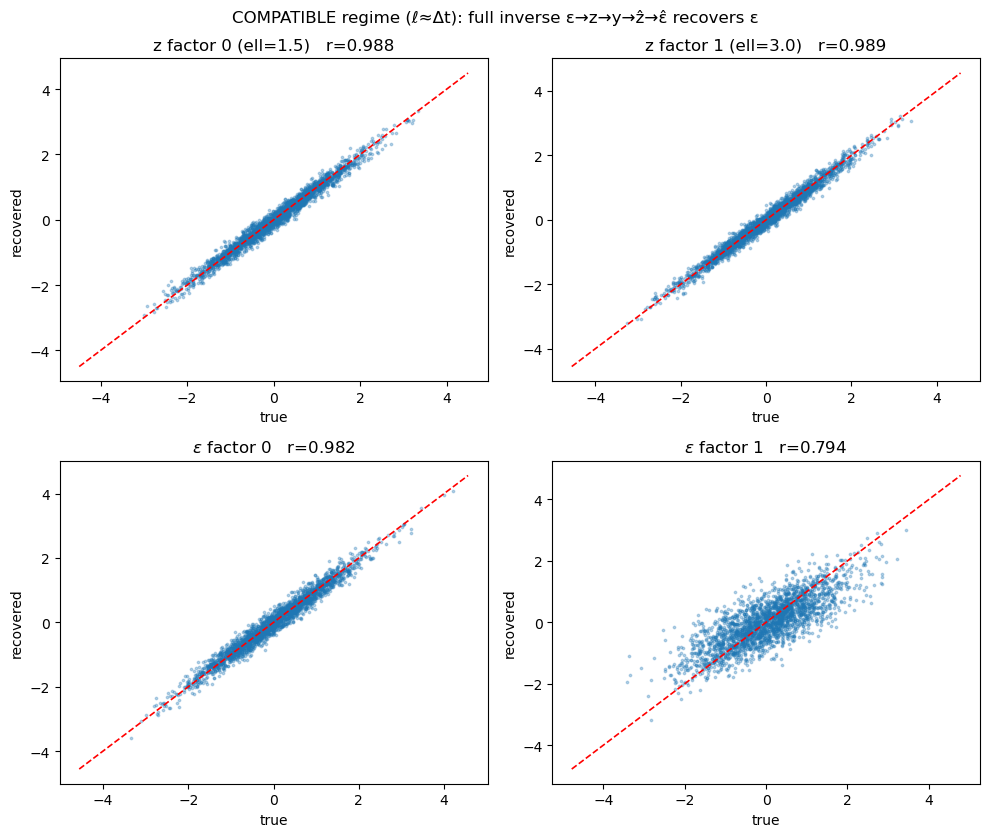

In [4]:
p, eps, z, y, z_hat, eps_hat = out["compatible (ell ~ dt)"]
fig, ax = plt.subplots(2,2,figsize=(10,8.5))
for k in range(Q):
    for row,(xt,xp,lab) in enumerate([(z[:,:,k],z_hat[:,:,k],f"z factor {k} (ell={p.ells[k]:.1f})"),
                                      (eps[:,:,k],eps_hat[:,:,k],f"$\\varepsilon$ factor {k}")]):
        a=ax[row,k]; xt=xt.reshape(-1); xp=xp.reshape(-1); idx=torch.randperm(len(xt))[:2500]
        a.scatter(xt[idx],xp[idx],s=3,alpha=.3); lim=max(xt.abs().max(),xp.abs().max())*1.05
        a.plot([-lim,lim],[-lim,lim],'r--',lw=1.2)
        a.set_title(f"{lab}   r={r(xt,xp):.3f}"); a.set_xlabel("true"); a.set_ylabel("recovered")
fig.suptitle("COMPATIBLE regime (ℓ≈Δt): full inverse ε→z→y→ẑ→ε̂ recovers ε", fontsize=12)
fig.tight_layout()


## Contrast: the same round trip when ℓ ≫ Δt (oversampled) — ε is lost

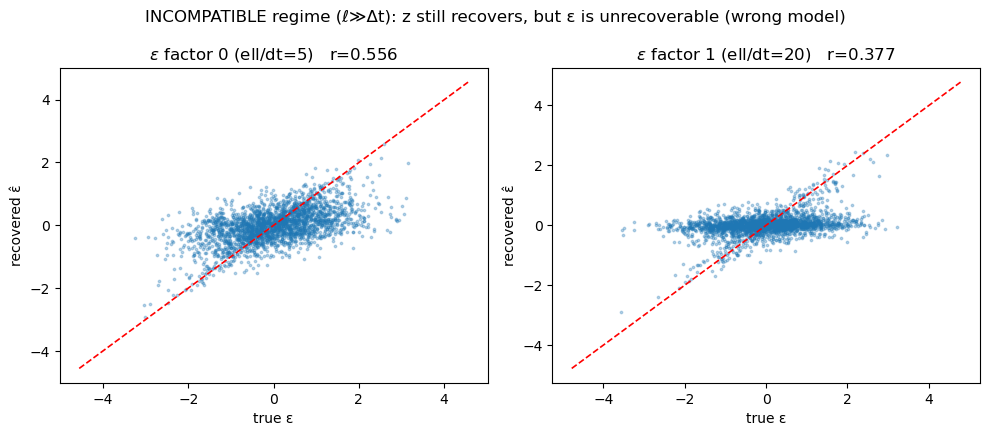

In [5]:
p2, eps2, z2, y2, z2h, e2h = out["incompatible (oversampled)"]
fig, ax = plt.subplots(1,2,figsize=(10,4.4))
for k in range(Q):
    et=eps2[:,:,k].reshape(-1); ep=e2h[:,:,k].reshape(-1); idx=torch.randperm(len(et))[:2500]
    ax[k].scatter(et[idx],ep[idx],s=3,alpha=.3); lim=max(et.abs().max(),ep.abs().max())*1.05
    ax[k].plot([-lim,lim],[-lim,lim],'r--',lw=1.2)
    ax[k].set_title(f"$\\varepsilon$ factor {k} (ell/dt={p2.ells[k]/p2.ts[1]:.0f})   r={r(et,ep):.3f}")
    ax[k].set_xlabel("true ε"); ax[k].set_ylabel("recovered ε̂")
fig.suptitle("INCOMPATIBLE regime (ℓ≫Δt): z still recovers, but ε is unrecoverable (wrong model)", fontsize=12)
fig.tight_layout()


## ε round-trip vs ℓ/Δt — the compatibility curve

Sweep the sampling step and watch mean r(ε) climb as ℓ/Δt → ~1.


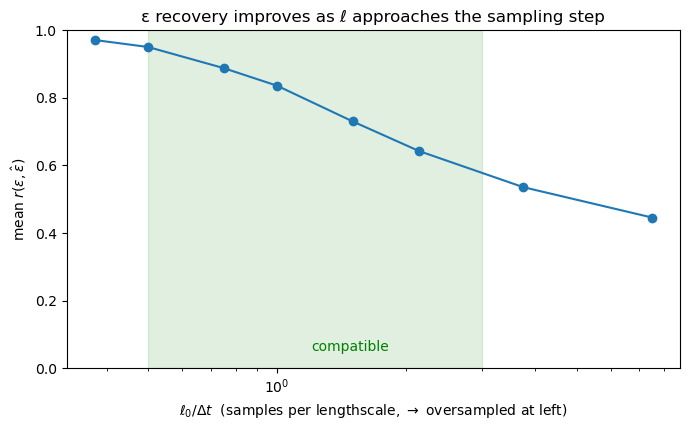

In [6]:
ratios=[]; recs=[]
for dt in [0.2,0.4,0.7,1.0,1.5,2.0,3.0,4.0]:
    p=make_params(dt=dt, ells=[1.5,3.0]); torch.manual_seed(1)
    eps=sample_eps(N,p); z=z_from_eps(eps,p); y=y_from_z(z,p); eh=eps_from_z(encode(y,p),p)
    ratios.append(1.5/dt); recs.append(np.mean([r(eps[:,:,k],eh[:,:,k]) for k in range(Q)]))
fig,ax=plt.subplots(figsize=(7,4.4))
ax.plot(ratios, recs, 'o-'); ax.set_xscale('log')
ax.set_xlabel(r"$\ell_0/\Delta t$  (samples per lengthscale, $\to$ oversampled at left)")
ax.set_ylabel(r"mean $r(\varepsilon,\hat\varepsilon)$"); ax.set_ylim(0,1)
ax.axvspan(0.5,3,alpha=.12,color='green'); ax.text(1.2,0.05,"compatible",color='green')
ax.set_title("ε recovery improves as ℓ approaches the sampling step"); fig.tight_layout()


## Summary

- The **encoder is literally the inverse of the decoder** (`y→ẑ→ε̂` undoes `ε→z→y`) — one forward,
  one inverse, fully symmetric.
- **z always round-trips nearly exactly.** **ε round-trips well when ℓ ≈ Δt** and degrades only when
  the model is oversampled (ℓ ≫ Δt) — which is a *model-specification* statement, not an estimator
  flaw: an oversampled smooth GP genuinely has no high-frequency content for z to pin down.
- So the full-inverse-map design is the right one; just keep the **lengthscale compatible with the
  sampling rate** (a few samples per lengthscale).
